In [1]:
!pip install xgboost

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error

from xgboost import XGBRegressor

In [3]:
df = pd.read_csv('/content/energy_dataset.csv')

weather_df = pd.read_csv('/content/weather_features.csv')

In [4]:
df.head()

,time,generation biomass,generation fossil brown coal/lignite,generation fossil coal-derived gas,generation fossil gas,generation fossil hard coal,generation fossil oil,generation fossil oil shale,generation fossil peat,generation geothermal,...,generation waste,generation wind offshore,generation wind onshore,forecast solar day ahead,forecast wind offshore eday ahead,forecast wind onshore day ahead,total load forecast,total load actual,price day ahead,price actual
0,2015-01-01 00:00:00+01:00,447.0,329.0,0.0,4844.0,4821.0,162.0,0.0,0.0,0.0,...,196.0,0.0,6378.0,17.0,NaN,6436.0,26118.0,25385.0,50.10,65.41
1,2015-01-01 01:00:00+01:00,449.0,328.0,0.0,5196.0,4755.0,158.0,0.0,0.0,0.0,...,195.0,0.0,5890.0,16.0,NaN,5856.0,24934.0,24382.0,48.10,64.92
2,2015-01-01 02:00:00+01:00,448.0,323.0,0.0,4857.0,4581.0,157.0,0.0,0.0,0.0,...,196.0,0.0,5461.0,8.0,NaN,5454.0,23515.0,22734.0,47.33,64.48
3,2015-01-01 03:00:00+01:00,438.0,254.0,0.0,4314.0,4131.0,160.0,0.0,0.0,0.0,...,191.0,0.0,5238.0,2.0,NaN,5151.0,22642.0,21286.0,42.27,59.32
4,2015-01-01 04:00:00+01:00,428.0,187.0,0.0,4130.0,3840.0,156.0,0.0,0.0,0.0,...,189.0,0.0,4935.0,9.0,NaN,4861.0,21785.0,20264.0,38.41,56.04


In [5]:
print(df.columns)

Index(['time', 'generation biomass', 'generation fossil brown coal/lignite',
       'generation fossil coal-derived gas', 'generation fossil gas',
       'generation fossil hard coal', 'generation fossil oil',
       'generation fossil oil shale', 'generation fossil peat',
       'generation geothermal', 'generation hydro pumped storage aggregated',
       'generation hydro pumped storage consumption',
       'generation hydro run-of-river and poundage',
       'generation hydro water reservoir', 'generation marine',
       'generation nuclear', 'generation other', 'generation other renewable',
       'generation solar', 'generation waste', 'generation wind offshore',
       'generation wind onshore', 'forecast solar day ahead',
       'forecast wind offshore eday ahead', 'forecast wind onshore day ahead',
       'total load forecast', 'total load actual', 'price day ahead',
       'price actual'],
      dtype='object')


In [6]:
df = df[['time', 'total load actual']]

In [7]:
df['time'] = pd.to_datetime(
    df['time'],
    errors='coerce',
    utc=True
)

In [8]:
df.dropna(subset=['time'], inplace=True)

In [9]:
df['hour'] = df['time'].dt.hour

df['day_of_week'] = df['time'].dt.dayofweek

df['month'] = df['time'].dt.month

df['weekend'] = df['day_of_week'].isin([5,6]).astype(int)

In [10]:
df['prev_hour_load'] = df['total load actual'].shift(1)

df['prev_day_load'] = df['total load actual'].shift(24)

In [11]:
df.dropna(inplace=True)

In [12]:
weather_df = weather_df[['dt_iso', 'temp']]

In [13]:
weather_df['dt_iso'] = pd.to_datetime(
    weather_df['dt_iso'],
    errors='coerce',
    utc=True
)

In [14]:
weather_df.rename(columns={'dt_iso':'time'}, inplace=True)

In [15]:
df = pd.merge(df, weather_df, on='time', how='left')

In [16]:
df['temp'] = df['temp'].fillna(df['temp'].mean())

In [17]:
df['is_holiday'] = (
    (df['day_of_week'] == 6)
).astype(int)

In [18]:
df['sin_hour'] = np.sin(
    2 * np.pi * df['hour']/24
)

df['cos_hour'] = np.cos(
    2 * np.pi * df['hour']/24
)

In [19]:
X = df[['hour',
        'day_of_week',
        'month',
        'weekend',
        'prev_hour_load',
        'prev_day_load',
        'temp',
        'is_holiday',
        'sin_hour',
        'cos_hour']]

y = df['total load actual']

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

In [21]:
model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5
)

In [22]:
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [23]:
predictions = model.predict(X_test)

In [24]:
rmse = np.sqrt(
    mean_squared_error(
        y_test,
        predictions
    )
)

print("RMSE:", rmse)

RMSE: 592.9606021638671


In [25]:
mape = mean_absolute_percentage_error(
    y_test,
    predictions
)

print("MAPE:", mape)

MAPE: 0.013565796229840096


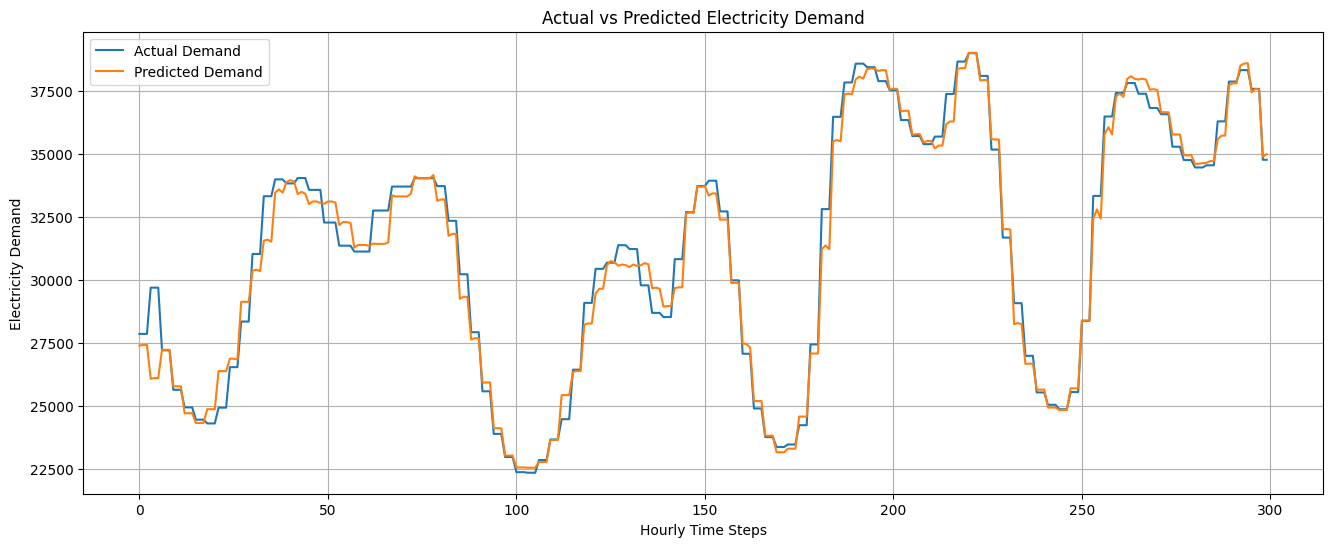

In [26]:
plt.figure(figsize=(16,6))

plt.plot(
    y_test.values[:300],
    label='Actual Demand'
)

plt.plot(
    predictions[:300],
    label='Predicted Demand'
)

plt.title(
    'Actual vs Predicted Electricity Demand'
)

plt.xlabel('Hourly Time Steps')

plt.ylabel('Electricity Demand')

plt.legend()

plt.grid(True)

plt.show()

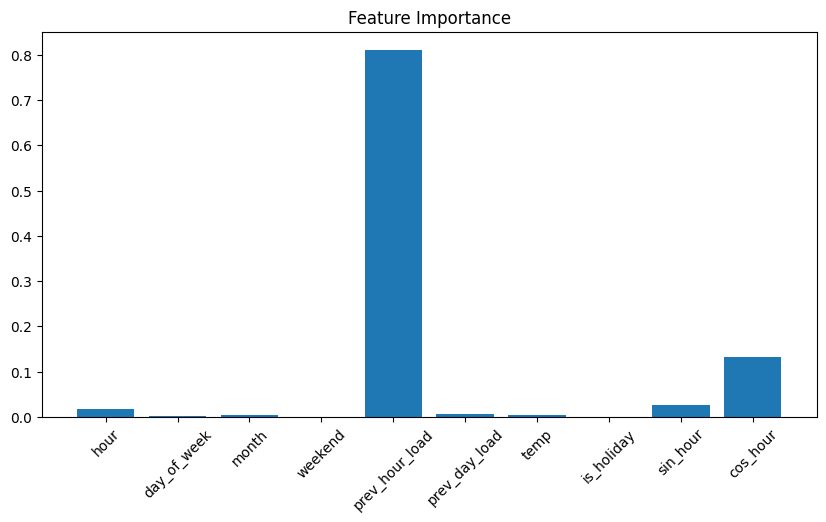

In [27]:
importance = model.feature_importances_

features = X.columns

plt.figure(figsize=(10,5))

plt.bar(features, importance)

plt.xticks(rotation=45)

plt.title('Feature Importance')

plt.show()

In [28]:
joblib.dump(model, 'model.pkl')

['model.pkl']

In [29]:
import os

print(os.path.getsize('model.pkl'))

279401


In [30]:
!pip install gradio

In [31]:
# =========================================================
# SMART GRID ELECTRICITY DEMAND FORECASTING DASHBOARD
# FINAL PROFESSIONAL HACKATHON VERSION
# =========================================================

!pip install gradio xgboost joblib plotly -q

import gradio as gr
import pandas as pd
import numpy as np
import joblib
import plotly.graph_objects as go

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_percentage_error
)

# =========================================================
# LOAD MODEL
# =========================================================

model = joblib.load('model.pkl')

# =========================================================
# LOAD DATASETS
# =========================================================

df = pd.read_csv('/content/energy_dataset.csv')

weather_df = pd.read_csv('/content/weather_features.csv')

# =========================================================
# PREPROCESSING
# =========================================================

df = df[['time', 'total load actual']]

df['time'] = pd.to_datetime(
    df['time'],
    errors='coerce',
    utc=True
)

df.dropna(subset=['time'], inplace=True)

# -----------------------------
# TIME FEATURES
# -----------------------------

df['hour'] = df['time'].dt.hour

df['day_of_week'] = df['time'].dt.dayofweek

df['month'] = df['time'].dt.month

df['weekend'] = (
    df['day_of_week']
    .isin([5,6])
    .astype(int)
)

# -----------------------------
# HISTORICAL FEATURES
# -----------------------------

df['prev_hour_load'] = (
    df['total load actual']
    .shift(1)
)

df['prev_day_load'] = (
    df['total load actual']
    .shift(24)
)

# =========================================================
# WEATHER DATA
# =========================================================

weather_df = weather_df[
    ['dt_iso', 'temp']
]

weather_df['dt_iso'] = pd.to_datetime(
    weather_df['dt_iso'],
    errors='coerce',
    utc=True
)

weather_df.rename(
    columns={'dt_iso':'time'},
    inplace=True
)

# Merge Weather
df = pd.merge(
    df,
    weather_df,
    on='time',
    how='left'
)

# Fill Missing Temperature
df['temp'] = df['temp'].fillna(
    df['temp'].mean()
)

# =========================================================
# EXTRA FEATURES
# =========================================================

df['is_holiday'] = (
    (df['day_of_week'] == 6)
).astype(int)

df['sin_hour'] = np.sin(
    2 * np.pi * df['hour'] / 24
)

df['cos_hour'] = np.cos(
    2 * np.pi * df['hour'] / 24
)

df.dropna(inplace=True)

df.reset_index(drop=True, inplace=True)

# =========================================================
# FEATURES
# =========================================================

X = df[
[
'hour',
'day_of_week',
'month',
'weekend',
'prev_hour_load',
'prev_day_load',
'temp',
'is_holiday',
'sin_hour',
'cos_hour'
]]

y = df['total load actual']

# =========================================================
# PREDICTIONS
# =========================================================

all_predictions = model.predict(X)

# =========================================================
# METRICS
# =========================================================

rmse = np.sqrt(
    mean_squared_error(
        y,
        all_predictions
    )
)

mape = mean_absolute_percentage_error(
    y,
    all_predictions
)

# =========================================================
# FORECAST FUNCTION
# =========================================================

def forecast(date_input, hour_input):

    selected_date = pd.to_datetime(
        date_input
    )

    # Feature Extraction
    day_of_week = selected_date.dayofweek

    month = selected_date.month

    weekend = (
        1 if day_of_week >= 5 else 0
    )

    is_holiday = (
        1 if day_of_week == 6 else 0
    )

    prev_hour_load = (
        df['total load actual']
        .iloc[-1]
    )

    prev_day_load = (
        df['total load actual']
        .iloc[-24]
    )

    temp = df['temp'].mean()

    # Time Encoding
    sin_hour = np.sin(
        2 * np.pi * hour_input / 24
    )

    cos_hour = np.cos(
        2 * np.pi * hour_input / 24
    )

    # Prediction Input
    input_data = np.array([[
        hour_input,
        day_of_week,
        month,
        weekend,
        prev_hour_load,
        prev_day_load,
        temp,
        is_holiday,
        sin_hour,
        cos_hour
    ]])

    # Predict
    prediction = model.predict(
        input_data
    )[0]

    # =====================================================
    # 24-HOUR FORECAST
    # =====================================================

    forecast_values = []

    hours = list(range(24))

    for h in hours:

        sin_h = np.sin(
            2 * np.pi * h / 24
        )

        cos_h = np.cos(
            2 * np.pi * h / 24
        )

        temp_input = np.array([[
            h,
            day_of_week,
            month,
            weekend,
            prev_hour_load,
            prev_day_load,
            temp,
            is_holiday,
            sin_h,
            cos_h
        ]])

        pred = model.predict(
            temp_input
        )[0]

        forecast_values.append(pred)

    # =====================================================
    # PEAK DEMAND
    # =====================================================

    peak_hour = np.argmax(
        forecast_values
    )

    peak_value = max(
        forecast_values
    )

    # =====================================================
    # FORECAST GRAPH
    # =====================================================

    forecast_fig = go.Figure()

    forecast_fig.add_trace(
        go.Scatter(
            x=hours,
            y=forecast_values,
            mode='lines+markers',
            name='Forecast',
            fill='tozeroy'
        )
    )

    forecast_fig.add_vline(
        x=peak_hour,
        line_dash="dash",
        line_color="red"
    )

    forecast_fig.update_layout(
        title="24-Hour Electricity Forecast",
        xaxis_title="Hour",
        yaxis_title="Predicted Demand (MW)",
        template="plotly_dark",
        height=500
    )

    # =====================================================
    # ACTUAL VS PREDICTED GRAPH
    # =====================================================

    comparison_fig = go.Figure()

    comparison_fig.add_trace(
        go.Scatter(
            x=list(range(24)),
            y=y.values[:24],
            mode='lines+markers',
            name='Actual'
        )
    )

    comparison_fig.add_trace(
        go.Scatter(
            x=list(range(24)),
            y=all_predictions[:24],
            mode='lines+markers',
            name='Predicted'
        )
    )

    comparison_fig.update_layout(
        title="Actual vs Predicted Demand",
        xaxis_title="Hour",
        yaxis_title="Electricity Demand (MW)",
        template="plotly_dark",
        height=500
    )

    # =====================================================
    # SUMMARY
    # =====================================================

    summary = f"""
Forecast Generated Successfully

Forecast Date:
{selected_date.date()}

Selected Hour:
{hour_input}:00

Predicted Electricity Demand:
{prediction:.2f} MW

Peak Forecast Hour:
{peak_hour}:00

Peak Predicted Demand:
{peak_value:.2f} MW

RMSE:
{rmse:.2f} MW

MAPE:
{mape*100:.2f} %

Temperature Used:
{temp:.2f} K

Model Struggles Most During:
- sudden demand spikes
- extreme weather conditions
- unusual holiday behavior
"""

    # KPI Cards
    pred_card = f"{prediction:.2f} MW"

    rmse_card = f"{rmse:.2f} MW"

    mape_card = f"{mape*100:.2f} %"

    peak_card = f"{peak_hour}:00"

    return (
        pred_card,
        rmse_card,
        mape_card,
        peak_card,
        summary,
        forecast_fig,
        comparison_fig
    )

# =========================================================
# MODERN PROFESSIONAL UI
# =========================================================

with gr.Blocks(
    theme=gr.themes.Monochrome()
) as demo:

    gr.Markdown("""
# ⚡ Smart Grid Electricity Demand Forecasting

### AI-Based Smart Energy Forecasting Dashboard
""")

    # =====================================================
    # KPI CARDS
    # =====================================================

    with gr.Row():

        pred_card = gr.Textbox(
            label="Predicted Demand"
        )

        rmse_card = gr.Textbox(
            label="RMSE"
        )

        mape_card = gr.Textbox(
            label="MAPE"
        )

        peak_card = gr.Textbox(
            label="Peak Hour"
        )

    # =====================================================
    # INPUT SECTION
    # =====================================================

    with gr.Row():

        with gr.Column(scale=1):

            date_input = gr.Textbox(
                label="Enter Date (YYYY-MM-DD)",
                value="2026-05-10"
            )

            hour_input = gr.Slider(
                0,
                23,
                value=12,
                label="Select Hour"
            )

            predict_btn = gr.Button(
                "Generate Forecast",
                size="lg"
            )

        with gr.Column(scale=2):

            summary_box = gr.Textbox(
                label="Forecast Summary",
                lines=12
            )

    # =====================================================
    # TABS
    # =====================================================

    with gr.Tabs():

        with gr.Tab("24-Hour Forecast"):

            forecast_plot = gr.Plot()

        with gr.Tab("Actual vs Predicted"):

            comparison_plot = gr.Plot()

        with gr.Tab("Deployment"):

            gr.Markdown("""
## Real-World Deployment

This system can integrate with:
- Smart meters
- IEX electricity market data
- Weather APIs
- MESCOM infrastructure

## Smart Grid Benefits
- peak demand management
- efficient load scheduling
- smarter electricity distribution
""")

        with gr.Tab("Model Analysis"):

            gr.Markdown("""
## Model Analysis

### Evaluation Metrics
- RMSE
- MAPE

### Model Challenges
The model struggles most during:
- sudden demand spikes
- unusual weather conditions
- holiday-like electricity behavior

### Future Improvements
- live weather integration
- real-time smart meter data
- advanced deep learning forecasting
""")

    # =====================================================
    # BUTTON ACTION
    # =====================================================

    predict_btn.click(
        fn=forecast,

        inputs=[
            date_input,
            hour_input
        ],

        outputs=[
            pred_card,
            rmse_card,
            mape_card,
            peak_card,
            summary_box,
            forecast_plot,
            comparison_plot
        ]
    )

demo.launch()

/tmp/ipykernel_4687/481825552.py:405: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://071e247ba1377238d7.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
